A criticcal question among the physical oceanographic research community is, "Can we use SWOT to estimate geostrophic surface currents?" The fact that SWOT has data across a swath means that we have information on the gradients from a single pass of the satellite. How convinient! We could, in theory, just do the calculation using the gradients of height over the swath. However,recall that the geostrophic balance requires sufficiently long time scales and large spatial scales. These criteria may no longer be met at the scales which SWOT resolves. 

• Can we identify a length scale below which SWOT SSH data may no longer be valid to infer surface velocities in the standing meander south of Tasmania region?
    For the denoised SSH, the optimal fitting kernel size is 9 points (18 km). Applied respectively to the original and denoised SSH fields, both kernel sizes correspond to an effective filtering length scale of approximately 25 km. SWOT provides accurate velocity estimates in excellent agreement with low‐pass filtered (>1 day) in‐situ velocity observations, even for higher velocities. In contrast, DUACS smooths out smaller‐scale features, resulting in significant discrepancies with ground‐truth velocities, especially in the higher velocity range.
• How significant are higher‐order balanced motions at the scales resolved by SWOT?
• Does the balanced surface velocity field derived from SWOT explain the small‐scale dispersion properties observed in drifter pairs deployed during the FOCUS voyage?

"As a step toward estimating accurate upper‐ocean velocities from SWOT data, we propose a novel approach by directly fitting spatial derivatives from SWOT SSH observations. This method reduces errors caused by noise and unbalanced SSH by adjusting the length scale used to derive geostrophic velocities and higher‐order balances."

In [16]:
# Geostrophic Velocity Computation and comparisons
# Comparison with Geostrophic velocity provided by the SWOT Product v3 product by
# 1. calculating the slope by fitting a linear plane kernel to 2D SSH observations - gradients by fitting planes of 9 × 9 pixels
# 2.calculating the slope a central grid point involves differencing adjacent SSH in both the x and y directions

### Across all data set adt field is used in the compuation of geostrophic velocites
###

In [17]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import matplotlib.cm as mplcm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys
sys.path.append('src/')
from src.diagnosis import *
import os

In [18]:
# if not on colab, then change path to the local path where the data is
path = '/Users/rodriguez/Projects/Data/SSiSLS/SWOT_LR_L3v3/expert/'
# dont forget to change this to your local one
files = sorted(os.listdir(path))

In [19]:
ds = xr.open_dataset(path+files[2])
ssha =ds.ssha_filtered
lon_swot = ds.longitude
lat_swot = ds.latitude
mdt  = ds.mdt
ugos_swot = ds.ugos_filtered
vgos_swot = ds.vgos_filtered

In [20]:
ds.ugos_filtered

<xarray.DataArray 'ugos_filtered' (num_lines: 9860, num_pixels: 69)> Size: 5MB
[680340 values with dtype=float64]
Coordinates:
    latitude   (num_lines, num_pixels) float64 5MB ...
    longitude  (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels
Attributes:
    comment:        Derived from [ssha_filtered] field using 2D spline fittin...
    institution:    CSIRO/CLS
    long_name:      Absolute geostrophic velocity: zonal component
    standard_name:  surface_geostrophic_eastward_sea_water_velocity
    units:          m/s
    source:         Tranchant et al. 2025; https://doi.org/10.22541/essoar.17...

In [21]:
params = dict(derivative = 'fit', # Derivative obtained by the fitting method instead of point difference
          n = 9, # 9*9 point kernels
          min_valid_points = 0.75, # Ratio of valid points to compute the derivative (e.g. 75% valid points are necessary to compute the derivatives, useful to avoid boundary effects)
          avoid_negative = False, # Parameter that avoid negative values in the SQRT using the GW formulation (leading to invalid values in the solutions)
          kernel = 'square', # can be circular or a square, the shape of the kernel
          )

## Diagnostics from original SSH
diag = compute_ocean_diagnostics_from_eta(ssha+mdt , lon_swot,lat_swot, **params)

Fitting derivatives on 680340 points (9*9 points kernel): 100%|██████████| 9860/9860 [00:12<00:00, 785.64it/s] 
/Users/rodriguez/Downloads/src/diagnosis.py:176: RuntimeWarning: invalid value encountered in sqrt
  ucg = 2*ug/(1+np.sqrt(c))
/Users/rodriguez/Downloads/src/diagnosis.py:177: RuntimeWarning: invalid value encountered in sqrt
  vcg = 2*vg/(1+np.sqrt(c))


In [22]:
dims = ds.ugos_filtered.dims
swot_derived = ds.assign(ugos_derived = (dims, diag['ug']), vgos_derived = (dims, diag['vg']))
#Magnitude
#Ug_derived = np.sqrt(swot_derived.ugos_derived**2 + swot_derived.vgos_derived**2)

In [23]:
## Defines the extend to plot
lon_min = -73
lon_max=-65
lat_min=36
lat_max= 45

In [24]:
## calculate adt 
ds['adt'] = ds['ssha_unfiltered'] + ds['mdt']
ds['adt'].attrs = {'units':'m','long_name':'Absolute dynamic topography'}


In [25]:
# We compute the slopes on the ADT as we computed in the previous question
adt = np.array(ds.adt)

# Compute the slopes
slope_alongtrack, slope_crosstrack = np.gradient(adt)
slope_alongtrack = slope_alongtrack / 2000 # OBS: Be aware of the units! Before we were happy with m/km, but now we need m/m!
slope_crosstrack = slope_crosstrack / 2000 # OBS: Be aware of the units! Before we were happy with m/km, but now we need m/m!
slope_magnitude = np.sqrt((slope_alongtrack)**2 + (slope_crosstrack)**2)


def R(theta):
    # For the definition see: https://en.wikipedia.org/wiki/Rotation_matrix
    return np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

# We have to determine the orbit angle theta
# A rough way is to know the inclination of SWOT is about 78 degrees:
theta = 180 - (90-78)
# But this is not entirely accurate.

# If we think about the cross-track and along-track slopes as a vector, we can gather all the SWOT observations into a 2xN matrix
# We use .reshape(-1) in order to reformat the 2D SWOT matrix into two columns and put them side by side
# Convert to N-E
slopes_vector = np.c_[slope_alongtrack.reshape(-1), slope_crosstrack.reshape(-1)].T
slopes_ne = R(np.deg2rad(theta)) @ slopes_vector


g = 9.82
Omega = 7.282e-5

# ---------------------------------------------------
# Coriolis parameter
# ---------------------------------------------------
f = 2 * Omega * np.sin(np.deg2rad(ds['latitude']))

# Now we compute the geostrophic currents from the equations
u = - g/f * slopes_ne[0,:].reshape(adt.shape)
v = g/f * slopes_ne[1,:].reshape(adt.shape)


/var/folders/t2/zy59c5kj1rb40c1n460mhp480000gq/T/ipykernel_9809/987001160.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 0.8, 0.71])


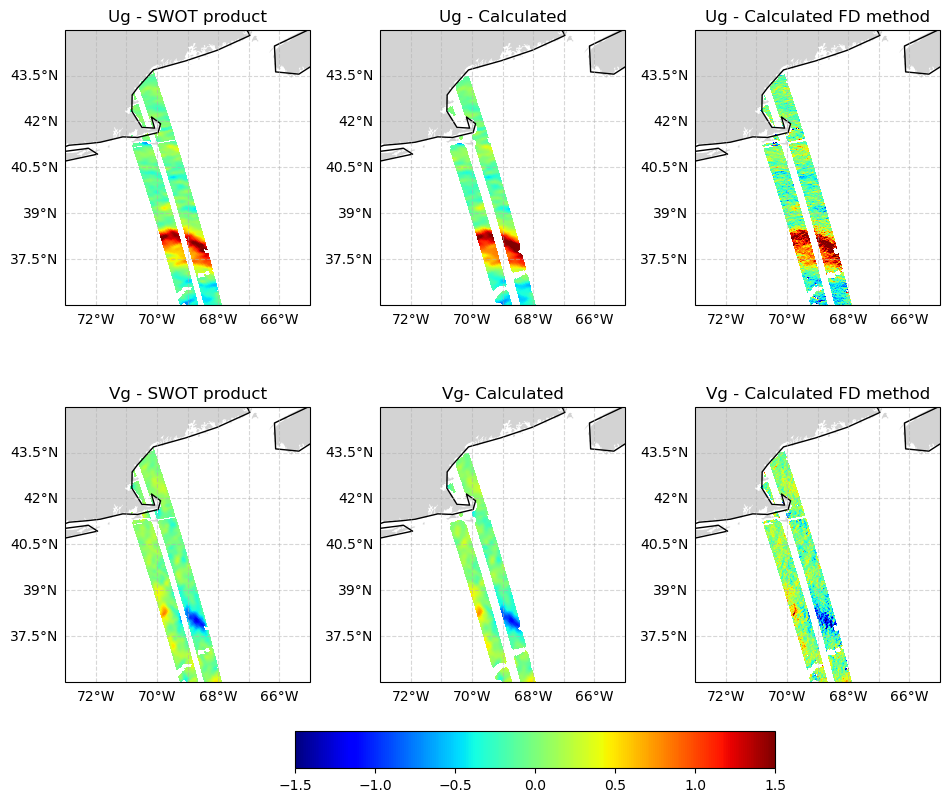

In [26]:
fig, axes = plt.subplots(2, 3,figsize=(12, 15), subplot_kw=dict(projection=ccrs.PlateCarree()),sharex=True,sharey=True)

pcm = axes[0,0].pcolormesh(lon_swot,lat_swot.latitude,ugos_swot,cmap='jet',
                           vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree())
axes[0,0].set_title("Ug - SWOT product")


pcm = axes[0,1].pcolormesh(swot_derived.longitude,swot_derived.latitude,swot_derived.ugos_derived,cmap='jet',
                           vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree())
axes[0,1].set_title("Ug - Calculated")

pcm = axes[0,2].pcolormesh(lon_swot,lat_swot,u,cmap='jet',
                           vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree())
axes[0,2].set_title("Ug - Calculated FD method")


pcm = axes[1,0].pcolormesh(lon_swot,lat_swot,vgos_swot,cmap='jet',
                           vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree())
axes[1,0].set_title("Vg - SWOT product")


pcm = axes[1,1].pcolormesh(swot_derived.longitude,swot_derived.latitude,swot_derived.vgos_derived,cmap='jet',
                           vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree())
axes[1,1].set_title("Vg- Calculated")

pcm = axes[1,2].pcolormesh(lon_swot,lat_swot,v,cmap='jet',vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree())
axes[1,2].set_title("Vg - Calculated FD method")

for ax in axes.flat:
    ax.coastlines(resolution="110m", linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

    gl = ax.gridlines(draw_labels=True,linestyle="--",alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_extent([lon_min, lon_max, lat_min, lat_max],crs=ccrs.PlateCarree())

cax = fig.add_axes([0.25, 0.12, 0.4, 0.025])

cb = fig.colorbar(pcm,cax=cax,orientation="horizontal")

plt.tight_layout(rect=[0, 0.08, 0.8, 0.71])

plt.show()